# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).

---

## Tasks

### Task 0: Course project dataset exploration (2p)

This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

In [2]:
# a) 
# IMF World economic outlook April 2026, https://www.kaggle.com/datasets/kanchana1990/imf-world-economic-outlook-april-2026

#b)
# The dataset contains the economic forecasts for different countries. 
# There are 24 different variables for each country. For example, names of the countries (string), 
# year of the economic outlook (integer), is_forecast (boolean) and Real_GDP_Growth_Pct (float).
# There are a total of 2901 rows of data at 91.5% completeness. 
# I plan to examine how inflation and GDP growth (both past and forecasted) move together

#c)
import pandas as pd
!pip install kagglehub
import kagglehub
import os
import seaborn as sns

# Download latest version
path = kagglehub.dataset_download("kanchana1990/imf-world-economic-outlook-april-2026")

print(os.listdir(path))

df = pd.read_csv(path + "/imf_weo_april_2026.csv")
df.describe()



['imf_weo_april_2026.csv']


,year,GDP_Nominal_USD_Bn,Real_GDP_Growth_Pct,GDP_Per_Capita_USD,GDP_PPP_USD_Bn,GDP_PPP_Per_Capita_USD,Inflation_CPI_Pct,Unemployment_Rate_Pct,Current_Account_Bal_USD_Bn,Current_Account_Pct_GDP,Govt_Gross_Debt_Pct_GDP,Govt_Net_Lending_Pct_GDP,Population_Mn,GDP_Growth_Momentum_3Y,Economic_Resilience_Score,Real_Purchasing_Power_Growth,Govt_Revenue_Pct_GDP,Import_Volume_Growth_Pct,Export_Volume_Growth_Pct
count,2901.000000,2895.000000,2897.000000,2895.000000,2900.000000,2900.000000,2891.000000,1628.000000,2876.000000,2875.000000,2843.000000,2891.000000,2901.000000,2900.000000,2900.000000,2899.000000,1130.000000,1405.000000,1405.000000
mean,2022.943468,568.986716,2.935312,19539.197403,969.719571,29787.937196,6.958215,7.349017,2.307947,-1.855165,58.527999,-2.835662,40.587789,2.969112,63.124400,-35.416523,26.623614,4.223474,5.122421
std,4.312641,2535.851817,4.723245,28331.467572,3692.458879,32095.641243,22.248993,6.134787,86.248633,9.612389,37.115193,6.076082,149.199602,3.482736,14.165767,1270.951437,14.075219,12.726164,33.681341
min,2016.000000,0.041000,-32.900000,244.862000,0.041000,601.413000,-7.700000,1.000000,-1338.687000,-46.700000,0.000000,-55.700000,0.010000,-25.800000,0.000000,-65393.800000,1.871600,-57.089000,-73.472200
25%,2019.000000,11.373500,1.600000,2682.660500,28.522500,6397.140500,2.000000,4.000000,-2.208000,-5.600000,35.550000,-4.900000,1.799000,1.567000,55.965000,-3.600000,17.652325,-1.496500,-1.690900
50%,2023.000000,46.844000,3.100000,7574.859000,108.854000,17911.960000,3.000000,5.700000,-0.296000,-2.000000,51.500000,-2.700000,8.545000,2.900000,65.370000,-0.400000,25.570550,4.235000,3.787400
75%,2027.000000,291.226500,4.800000,25361.346500,540.789750,43876.144500,5.700000,8.600000,1.204500,2.300000,73.100000,-0.700000,29.715000,4.450000,72.755000,1.700000,33.059300,9.846700,9.389600
max,2030.000000,37677.878000,46.100000,252007.222000,55279.714000,212382.703000,438.100000,61.300000,749.263000,40.000000,345.500000,52.400000,1525.139000,46.967000,98.930000,74.400000,147.181400,73.517900,1045.449300


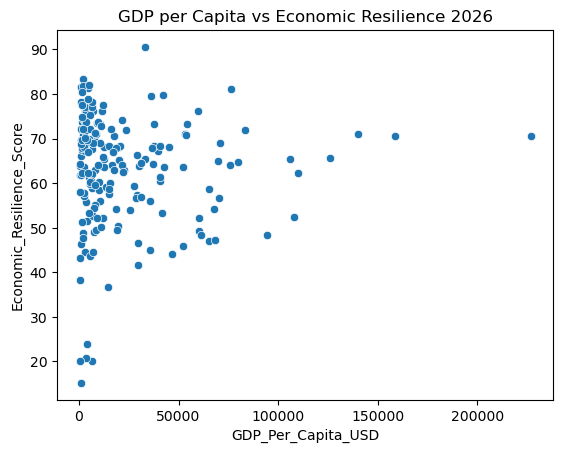

In [3]:
# making a scatterplot that illustrates the gdp (x axis) and the economic resilience (y axis) in 2026
import seaborn as sns
import matplotlib.pyplot as plt

#we include only data for the year 2026:
df_2026 = df[df["year"] == 2026]
sns.scatterplot(
    data=df_2026,
    x="GDP_Per_Capita_USD",
    y="Economic_Resilience_Score"
)

plt.title("GDP per Capita vs Economic Resilience 2026")
plt.show()

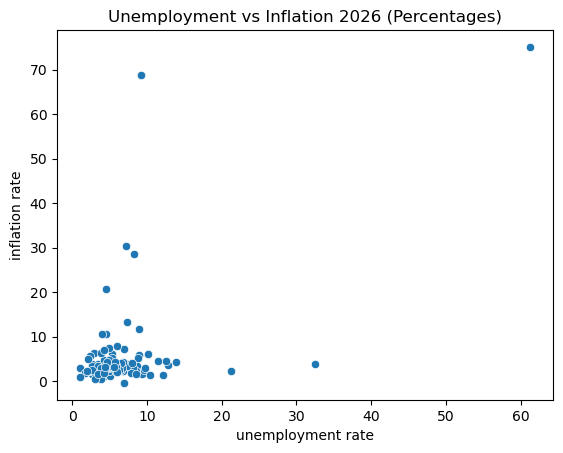

In [4]:
# making a graph that illustrates the unemployment rate (x-axis) and inflation rate (y-axis)

sns.scatterplot(
    data=df_2026,
    x="Unemployment_Rate_Pct",
    y="Inflation_CPI_Pct"
)

plt.title("Unemployment vs Inflation 2026 (Percentages)")
plt.xlabel("unemployment rate")
plt.ylabel("inflation rate")
plt.show()

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [5]:
import os
from dotenv import load_dotenv
load_dotenv("API.env")
API_Key = os.environ.get("API_Key")
print(f"First five characters of API: {API_Key[:5]}")

First five characters of API: 4310a


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.

b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

Hint: The API documentation helps on how to use it, but also using AI is recommended to help with formulating the GET request if you get stuck. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [6]:
# a)
import requests

tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

all_stocks = []

for ticker in tickers:
    url = f"http://api.marketstack.com/v1/eod?access_key={API_Key}&symbols={ticker}&date_from=2026-03-01&date_to=2026-03-31"

    response = requests.get(url)

    print("Status code:", response.status_code)
    
    if response.status_code == 200:
        data = response.json()["data"]

        print(ticker)
        print("March data:", data[0])
        all_stocks += data

Status code: 200
META
March data: {'open': 549.98, 'high': 573.69, 'low': 546.77, 'close': 572.13, 'volume': 32809500.0, 'adj_high': 573.69, 'adj_low': 546.77, 'adj_close': 572.13, 'adj_open': 549.98, 'adj_volume': 32898272.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'META', 'exchange': 'ARCX', 'date': '2026-03-31T00:00:00+0000'}
Status code: 200
AAPL
March data: {'open': 247.89, 'high': 255.48, 'low': 247.101, 'close': 253.79, 'volume': 48770963.0, 'adj_high': 255.48, 'adj_low': 247.101, 'adj_close': 253.79, 'adj_open': 247.91, 'adj_volume': 49598091.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AAPL', 'exchange': 'XNAS', 'date': '2026-03-31T00:00:00+0000'}
Status code: 200
AMZN
March data: {'open': 204.875, 'high': 210.28, 'low': 204.14, 'close': 208.27, 'volume': 57843337.0, 'adj_high': 210.28, 'adj_low': 204.14, 'adj_close': 208.27, 'adj_open': 204.845, 'adj_volume': 58470078.0, 'split_factor': 1.0, 'dividend': 0.0, 'symbol': 'AMZN', 'exchange': 'XNAS', 'date': '2026-0

In [7]:
# b)
df_March2026 = pd.DataFrame(all_stocks)

df_March2026.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


In [8]:
# c)
summary=df_March2026.describe()
print(summary)

             open        high         low       close        volume  \
count  110.000000  110.000000  110.000000  110.000000  1.100000e+02   
mean   294.918495  298.284272  291.148983  294.589818  3.246851e+07   
std    176.341061  178.239908  173.454381  175.731183  1.572011e+07   
min     91.370000   91.880000   90.690000   90.920000  8.940900e+06   
25%    207.170000  209.442500  204.752000  207.820000  1.976597e+07   
50%    254.045000  255.911500  251.187500  253.340000  3.366301e+07   
75%    304.521250  307.915000  301.045000  305.940000  4.164059e+07   
max    662.150000  672.750000  657.671100  667.730000  8.798132e+07   

         adj_high     adj_low   adj_close    adj_open    adj_volume  \
count  110.000000  110.000000  110.000000  110.000000  1.100000e+02   
mean   298.287986  291.144397  294.589818  294.914900  3.333989e+07   
std    178.240562  173.454848  175.731183  176.343236  1.600744e+07   
min     91.880000   90.690000   90.920000   91.310000  8.977162e+06   
25%  

In [9]:
returns = []

for symbol in df_March2026["symbol"].unique():
    stock = df_March2026[df_March2026["symbol"] == symbol]

    stock["date"] = pd.to_datetime(stock["date"])
    stock = stock.sort_values("date")
    
    first_close = stock["close"].iloc[0]
    last_close = stock["close"].iloc[-1]

    return_pct = ((last_close - first_close) / first_close) * 100

    returns.append({
        "symbol": symbol,
        "first_close": first_close,
        "last_close": last_close,
        "return_%": return_pct
    })

returns_df = pd.DataFrame(returns)

best = returns_df.loc[returns_df["return_%"].idxmax()]
worst = returns_df.loc[returns_df["return_%"].idxmin()]

print(returns_df)
print("\n best performer: ", best)
print("\n worst performer: ", worst)

  symbol  first_close  last_close   return_%
0   META       653.56      572.13 -12.459453
1   AAPL       264.72      253.79  -4.128891
2   AMZN       208.39      208.27  -0.057584
3   NFLX        97.09       96.15  -0.968174
4   GOOG       306.36      286.86  -6.365061

 best performer:  symbol             AMZN
first_close      208.39
last_close       208.27
return_%      -0.057584
Name: 2, dtype: object

 worst performer:  symbol              META
first_close       653.56
last_close        572.13
return_%      -12.459453
Name: 0, dtype: object


C:\Users\matts\AppData\Local\Temp\ipykernel_11560\1912009434.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock["date"] = pd.to_datetime(stock["date"])
C:\Users\matts\AppData\Local\Temp\ipykernel_11560\1912009434.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock["date"] = pd.to_datetime(stock["date"])
C:\Users\matts\AppData\Local\Temp\ipykernel_11560\1912009434.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

Text(0.5, 1.0, 'Closing prices March 2026')

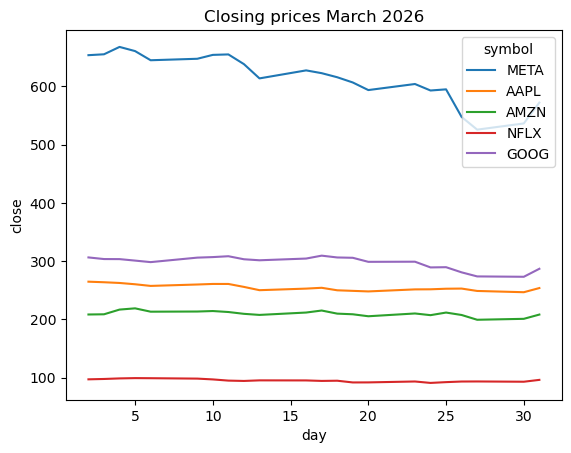

In [10]:
# a)
df_March2026["date"] = pd.to_datetime(df_March2026["date"])

# making a day column so that all the dates fit on the x axis
df_March2026["day"] = df_March2026["date"].dt.day

sns.lineplot(
    x="day",
    y="close",
    hue="symbol",
    data=df_March2026
)
plt.title("Closing prices March 2026")

Text(0.5, 1.0, 'Total returns March 2026')

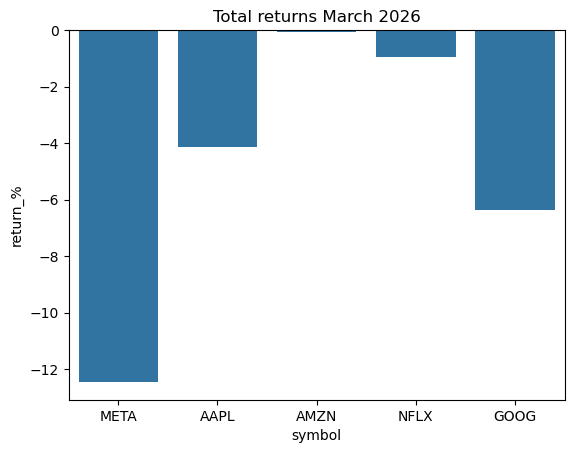

In [11]:
# b)
sns.barplot(
    data=returns_df,
    x="symbol",
    y="return_%"
)
plt.title("Total returns March 2026")

<Axes: xlabel='day', ylabel='symbol'>

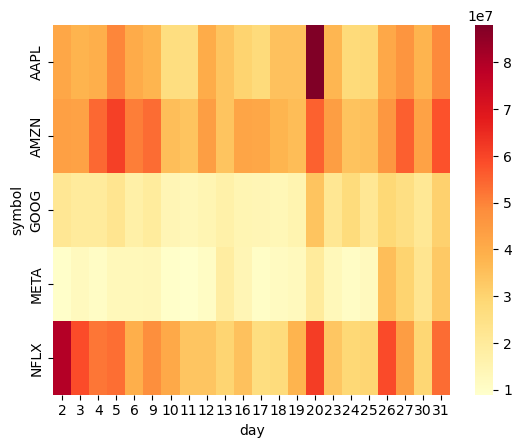

In [12]:
# c)
pivot = pd.pivot_table(
    df_March2026,
    values = "volume",
    index = "symbol",
    columns = "day",
    aggfunc = "mean"
)

sns.heatmap(pivot, annot=False, fmt=".2f", cmap="YlOrRd")

### Task 4: Exporting and importing data (1p)

a) Export the JSON data retrieved in Task 2a as a JSON file `stockdata.json` into a subfolder called `exports`.

b) Export the DataFrame from Task 2b as a CSV file `stockdata.csv` into the same `exports` subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [13]:
os.makedirs("exports", exist_ok=True)


### Task 5: Querying the Northwind database (1p)

Download an SQLite version of Microsoft's Northwind database (from [https://github.com/jpwhite3/northwind-SQLite3](https://github.com/jpwhite3/northwind-SQLite3), press the Download Here button). Connect to the database using `sqlite3`.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing `ProductName`, `UnitPrice`, and `UnitsInStock`. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the `Orders`, `Customers`, and `Order Details` tables to show `CompanyName`, `OrderID`, `OrderDate`, `ShipCountry`, and the line total (`UnitPrice * Quantity`) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

Hint: The SQL query in 5c should look something like this:

```
    SELECT columnNameX,
           columnNameX,
           columnNameX,
           columnNameX,
           columnNameX * columnNameX AS LineTotal
    FROM SomeTable o
    JOIN SomeTable c ON SomeTable.id = OtherTable.id
    JOIN SomeTable od ON SomeTable.id = OtherTable.id
    WHERE columnName = countryName
```

Hint: If you are unfamiliar with SQL, using AI to write the queries is a good idea. Remember to verify though that the column and table names are correct and not hallucinated. Microsoft Copilot is usually very bad so I suggest using Claude, ChatGPT or Le Chat.

In [14]:
# a)
import sqlite3
connection = sqlite3.connect("northwind.db")
db = connection.cursor()

db.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = db.fetchall()

for table in tables:
    print(table[0])

Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [15]:
# b)
over30 = db.execute("SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30;")
rows = over30.fetchall()
df_products = pd.DataFrame(rows, columns = ["ProductName", "UnitPrice", "UnitsInStock"])
df_products

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [16]:
# c)
query = """
SELECT 
    c.CompanyName,
    o.OrderID,
    o.OrderDate,
    o.ShipCountry,
    od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

cursor = db.execute(query)
rows = cursor.fetchall()

df_orders = pd.DataFrame(rows, columns=[col[0] for col in cursor.description])
df_orders

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


### Task 6: Visualizing Northwind data (1p)

Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins `OrderDetails`, `Products`, and `Categories` using inner joins to compute the total revenue (`UnitPrice * Quantity`) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

Hint: The SQL query in 6c should look something like this:

```
    SELECT columnName1,
           SUM(columnName2 * columnName3) AS newColumnName
    FROM table1 od
    JOIN table2 p ON table1_id = table2_id
    JOIN table3 cat ON table2_id = table3_id
    GROUP BY columnName1
```

In [22]:
# a)
orders_per_customer = df_orders.groupby("CompanyName")["OrderID"].nunique()
best_customers = orders_per_customer.sort_values(ascending = False).head(10)
best_customers

CompanyName
QUICK-Stop                 56
Ottilies Käseladen         40
IT                         40
Frankenversand             38
Königlich Essen            36
Great Lakes Food Market    35
Toms Spezialitäten         35
Lehmanns Marktstand        34
B's Beverages              32
Island Trading             31
Name: OrderID, dtype: int64

Text(0.5, 0, 'Orders')

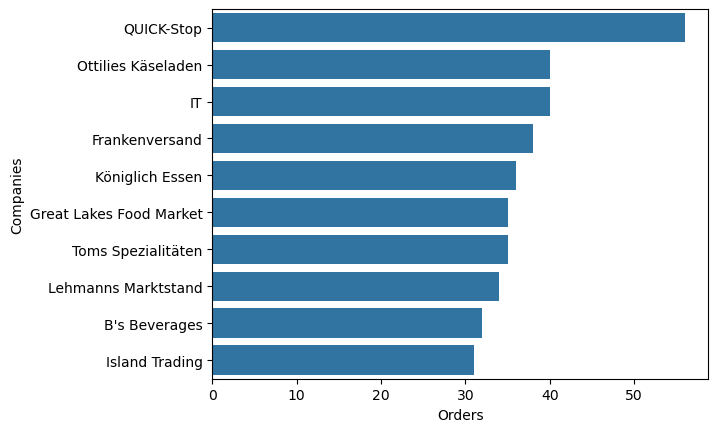

In [23]:
sns.barplot(
    x=best_customers.values,
    y=best_customers.index
)
plt.ylabel("Companies")
plt.xlabel("Orders")

Text(0, 0.5, 'Density')

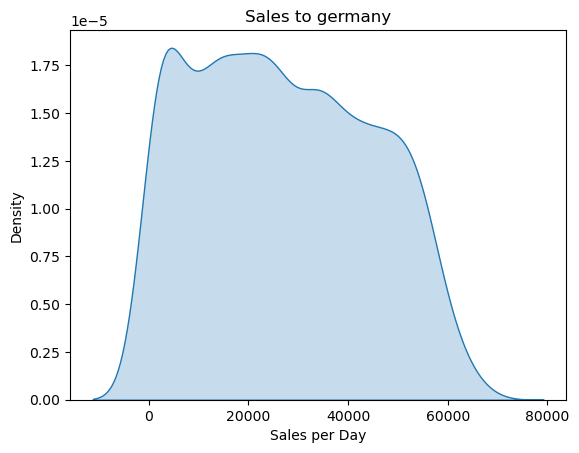

In [20]:
# b) 
germany_orders = df_orders[df_orders["ShipCountry"] == "Germany"]
daily_sales = germany_orders.groupby("OrderDate")["LineTotal"].sum()

sns.kdeplot(data=daily_sales, fill=True)

plt.title("Sales to germany")
plt.xlabel("Sales per Day")
plt.ylabel("Density")


In [21]:
# c) 
query = """
SELECT 
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
INNER JOIN Products p ON od.ProductID = p.ProductID
INNER JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName;
"""

cursor = db.execute(query)

df_revenue = pd.DataFrame(
    cursor.fetchall(),
    columns=[col[0] for col in cursor.description]
)

df_revenue

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


### Task 7: Comparing Python to SQL (1p)

a) Write a SQL query that retrieves the full `Products` table and the full `Categories` table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on `CategoryID`.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using `%%time` or `time.time()`, compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [28]:
# a)
query_products = "SELECT * FROM Products;"
cursor_products = db.execute(query_products)

df_products = pd.DataFrame(
    cursor_products.fetchall(),
    columns=[col[0] for col in cursor_products.description]
)

query_categories = "SELECT * FROM Categories;"
cursor_categories = db.execute(query_categories)

df_categories = pd.DataFrame(
    cursor_categories.fetchall(),
    columns=[col[0] for col in cursor_categories.description]
)

df_categories.head()


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [29]:
df_products.head()

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


In [31]:
# b) 
inner = pd.merge(df_categories, df_products, how ="inner", on ="CategoryID")
display(inner)
print()

,CategoryID,CategoryName,Description,Picture,ProductID,ProductName,SupplierID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,1,Chai,1,10 boxes x 20 bags,18.00,39,0,10,0
1,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,2,Chang,1,24 - 12 oz bottles,19.00,17,40,25,0
2,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,24,Guaraná Fantástica,10,12 - 355 ml cans,4.50,20,0,0,1
3,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,34,Sasquatch Ale,16,24 - 12 oz bottles,14.00,111,0,15,0
4,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,35,Steeleye Stout,16,24 - 12 oz bottles,18.00,20,0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,8,Seafood,Seaweed and fish,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,41,Jack's New England Clam Chowder,19,12 - 12 oz cans,9.65,85,0,10,0
73,8,Seafood,Seaweed and fish,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,45,Rogede sild,21,1k pkg.,9.50,5,70,15,0
74,8,Seafood,Seaweed and fish,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,46,Spegesild,21,4 - 450 g glasses,12.00,95,0,0,0
75,8,Seafood,Seaweed and fish,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...,58,Escargots de Bourgogne,27,24 pieces,13.25,62,0,20,0


In [52]:
# c)
import time
start = time.time()

orders = pd.read_sql_query("SELECT * FROM \"Order Details\"", connection)
products = pd.read_sql_query("SELECT * FROM Products", connection)
categories = pd.read_sql_query("SELECT * FROM Categories", connection)

all_df = orders.merge(products, on="ProductID", how="inner")
all_df = all_df.merge(categories, on="CategoryID", how="inner")
print(all_df.columns)

all_df["Revenue"] = all_df["UnitPrice_x"] * all_df["Quantity"]

df_revenues = all_df.groupby("CategoryName")["Revenue"].sum()
end = time.time()
df_revenues
PythonTime = end - start
print("Took", end - start, "seconds")



Index(['OrderID', 'ProductID', 'UnitPrice_x', 'Quantity', 'Discount',
       'ProductName', 'SupplierID', 'CategoryID', 'QuantityPerUnit',
       'UnitPrice_y', 'UnitsInStock', 'UnitsOnOrder', 'ReorderLevel',
       'Discontinued', 'CategoryName', 'Description', 'Picture'],
      dtype='object')
Took 1.8307528495788574 seconds


In [53]:
#testing against the SQL version
SQLstart = time.time()

query = """
SELECT 
    c.CategoryName,
    SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
INNER JOIN Products p ON od.ProductID = p.ProductID
INNER JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName;
"""

cursor = db.execute(query)

df_revenue = pd.DataFrame(
    cursor.fetchall(),
    columns=[col[0] for col in cursor.description]
)
SQLend = time.time()
df_revenue
SQLtime = SQLend - SQLstart
print("Took", SQLend - SQLstart, "seconds")


Took 0.774735689163208 seconds


In [54]:
print("The merge done with SQL was", PythonTime - SQLtime,  "faster than with Python.")

The merge done with SQL was 1.0560171604156494 faster than with Python.


### Task 8: Wide and long format (1p)

You are given two datasets. The first is in wide format:

```python
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
```

The second is in long format:

```python
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
```

a) Convert `wide_data` from wide to long format using `pd.melt()`. Print the DataFrame before and after conversion.

b) Convert `long_data` from long to wide format using `.pivot()`. Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [73]:
# a)
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
wide_data

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [74]:
sales_long = wide_data.melt(
    id_vars="store",
    var_name="Time",
    value_name="Sales"
)
sales_long

,store,Time,Sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [75]:
# b)
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
long_data

,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


In [76]:
sales_wide = long_data.pivot(
    index ="month",
    columns ="product",
    values="units_sold"
)
sales_wide

product,Laptop,Phone
month,,
Feb,50,110
Jan,45,120
Mar,55,130


In [81]:
# c) 
wide_data1 = sales_long.pivot(
    index = "store",
    columns = "Time",
    values = "Sales"
)

#We need to do this to make "Time" from the columns 
wide_data1.columns.name = None
#And this to include the 0,1,2 in the left hand side
wide_data1 = wide_data1.reset_index()

wide_data1

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [64]:
#Checking if it matches with the original (wide_data)
wide_data

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


In [84]:
#first we need to reset the wide dataframe's index, because there is no column named "month" there.
sales_wide = sales_wide.reset_index()
long_data1 = sales_wide.melt(
    id_vars ="month",
    var_name="product",
    value_name ="units_sold"
)
long_data1

,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130


In [85]:
#Checking with the original
long_data

,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130
